# LOCO evaluation and error analysis

This notebook analyses this project's results and evaluates whether a ResNet-18 model pre-trained on ImageNet and trained on labelled fluorescence images can predict the mechanism of action (MoA) of unseen compounds excluded from training. Three complete runs use seeds 42, 43, and 44, covering 2,528 images and 12 MoA classes. The analysis compares images and compound predictions, examines errors and confidence, and evaluates the CNN against a simple training-fold majority baseline.


In [30]:
from pathlib import Path
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

start = Path(os.environ.get("MOA_PROJECT_ROOT", Path.cwd())).resolve()
ROOT = next(
    (p for p in (start, *start.parents) if (p / "src/dataset.py").is_file()),
    None,
)

OUT = Path(
    os.environ.get("MOA_ANALYSIS_OUT", ROOT / "analysis")
) / "results"
OUT.mkdir(parents=True, exist_ok=True)

RUN_NAMES = ["loco_full_v1", "loco_full_v1_seed43", "loco_full_v1_seed44"]
PRIMARY_RUN = "loco_full_v1"

BOOTSTRAP_SEED = 2026
N_BOOTSTRAP = 2000

plt.rcParams.update({
    "figure.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(OUT / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

image_path = ROOT / "data/raw/BBBC021_v1_image.csv"
moa_path = ROOT / "data/raw/BBBC021_v1_moa.csv"

metadata = pd.read_csv(image_path).merge(
    pd.read_csv(moa_path),
    how="inner",
    validate="many_to_one",
    left_on=["Image_Metadata_Compound", "Image_Metadata_Concentration"],
    right_on=["compound", "concentration"],
)
metadata = metadata.loc[metadata.moa.ne("DMSO")].reset_index(drop=True)

class_names = sorted(metadata.moa.unique())
label_mapping = {name: i for i, name in enumerate(class_names)}
metadata["label"] = metadata.moa.map(label_mapping)

K = len(class_names)
class_ids = np.arange(K)
prob_cols = [f"prob_class_{i}" for i in class_ids]

def score(y, pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y, pred, labels=class_ids, zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(y, pred)),
        "balanced_accuracy": float(recall[support > 0].mean()),
        "macro_f1": float(f1.mean()),
        "weighted_f1": float(np.average(f1, weights=support)),
    }

## Load complete runs and audit saved predictions

Checks for test coverage, valid probability vectors, and compound leakage between training, validation and test sets.

In [31]:
def load_run(name):
    base = ROOT / "results" / name
    if not (base / "pooled/predictions.csv").exists():
        print(f"Not available as a completed run: {name}")
        return None

    files = [base / "pooled/predictions.csv", base / "split_information.json",
             base / "config.json", base / "results.csv", base / "pooled/metrics.json"]

    p = pd.read_csv(files[0]).sort_values("dataset_index").reset_index(drop=True)
    splits = json.loads(files[1].read_text())
    config = json.loads(files[2].read_text())
    folds = pd.read_csv(files[3])
    saved = json.loads(files[4].read_text())
    if len(splits) != metadata.compound.nunique() or len(p) != len(metadata):
        print(f"Incomplete coverage; excluded: {name}")
        return None

    assert p.dataset_index.tolist() == list(metadata.index), name
    assert p.fold.nunique() == len(splits) == len(folds), name
    assert len({s["fold"] for s in splits}) == len(splits), name
    assert np.array_equal(p.true_label, metadata.label), name
    assert np.array_equal(p.true_moa, metadata.moa), name
    assert np.array_equal(p.test_compound, metadata.compound), name
    for column in ["Image_Metadata_Concentration", "Image_Metadata_Plate_DAPI",
                   "Image_Metadata_Well_DAPI", "Replicate"]:
        assert np.array_equal(p[column], metadata[column]), column
    probabilities = p[prob_cols].to_numpy()
    assert np.isfinite(probabilities).all() and (probabilities >= 0).all(), name
    assert np.allclose(probabilities.sum(axis=1), 1, atol=1e-5), name
    assert np.array_equal(probabilities.argmax(axis=1), p.predicted_label), name

    p["correct"] = p.true_label.eq(p.predicted_label)
    p["confidence"] = probabilities.max(axis=1)

    signatures = {}

    for s in splits:
        indices = [s[f"{key}_indices"] for key in ["train", "val", "test"]]
        assert all(len(v) == len(set(v)) and set(v) <= set(metadata.index) for v in indices)
        a, b, c = map(set, indices)
        assert not (a & b or a & c or b & c)
        assert a | b | c == set(metadata.index)
        ca, cb, cc = [set(metadata.iloc[v].compound) for v in indices]
        assert not (ca & cb or ca & cc or cb & cc)
        assert cc == {s["test_compound"]}
        part = p.loc[p.fold.eq(s["fold"])]
        assert set(part.dataset_index) == c
        assert np.isclose(part.correct.mean(), folds.set_index("fold").loc[s["fold"], "accuracy"])
        signatures[s["test_compound"]] = [sorted(a), sorted(b), sorted(c)]
    for key, value in score(p.true_label, p.predicted_label).items():
        assert np.isclose(value, saved[key]), (name, key)
    return {"predictions": p, "splits": splits, "config": config,
            "folds": folds, "signature": signatures}

runs = {}

for name in RUN_NAMES:
    loaded = load_run(name)
    if loaded is not None:
        runs[name] = loaded

reference_tests = {
    compound: parts[2]
    for compound, parts in runs[PRIMARY_RUN]["signature"].items()
}

for name, run in runs.items():
    test_sets = {
        compound: parts[2]
        for compound, parts in run["signature"].items()
    }
    assert test_sets == reference_tests, f"Different test sets: {name}"

print("Validated runs:", list(runs))

Validated runs: ['loco_full_v1', 'loco_full_v1_seed43', 'loco_full_v1_seed44']


## CNN versus training-fold majority baseline

The dummy classifier predicts the most frequent image label in each fold's
training subset. Validation and test labels never select that label. Ties use
the lowest numeric class ID. No image loading or model training is required.

A constant chosen from the entire labelled dataset is a descriptive reference,
not the fitted LOCO dummy baseline. Majority-class performance can be below
uniform random expectation because holding out a large compound changes the
training class distribution.

In [32]:
def aggregate(table, groups):
    grouped = table.groupby(groups, sort=True, observed=True)
    assert grouped.true_label.nunique().eq(1).all()

    result = grouped[prob_cols].mean().reset_index()
    truth = grouped.true_label.first().reset_index()
    result = result.merge(truth, on=groups, validate="one_to_one")

    result["predicted_label"] = result[prob_cols].to_numpy().argmax(axis=1)
    result["correct"] = result.true_label.eq(result.predicted_label)
    return result


summary_rows, baseline_rows = [], []

for name, run in runs.items():
    p = run["predictions"]
    dummy = p.copy()

    for s in run["splits"]:
        counts = np.bincount(
            metadata.iloc[s["train_indices"]].label,
            minlength=K,
        )
        chosen = int(counts.argmax())
        mask = dummy.fold.eq(s["fold"])

        dummy.loc[mask, "predicted_label"] = chosen
        dummy.loc[mask, prob_cols] = np.eye(K)[chosen]

        baseline_rows.append({
            "run": name,
            "fold": s["fold"],
            "test_compound": s["test_compound"],
            "majority_moa": class_names[chosen],
        })

    dummy["correct"] = dummy.true_label.eq(dummy.predicted_label)

    for method, table in [("CNN", p), ("training_majority", dummy)]:
        views = {
            "image": table,
            "compound_equal_images": aggregate(table, ["test_compound"]),
        }

        for unit, values in views.items():
            result = {
                "run": name,
                "method": method,
                "unit": unit,
                "n": len(values),
                **score(values.true_label, values.predicted_label),
            }
            result["mean_compound_accuracy"] = (
                values.groupby("test_compound").correct.mean().mean()
            )
            summary_rows.append(result)
            values.to_csv(
                OUT / f"{name}_{method}_{unit}.csv",
                index=False,
            )

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT / "metrics_by_run_method_unit.csv", index=False)
pd.DataFrame(baseline_rows).to_csv(
    OUT / "baseline_choices.csv",
    index=False,
)

display(summary.round(4))
display(
    summary.groupby(["method", "unit"])[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
            "mean_compound_accuracy",
        ]
    ].agg(["mean", "std"]).round(4)
)

,run,method,unit,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,mean_compound_accuracy
0,loco_full_v1,CNN,image,2528,0.6713,0.8253,0.7193,0.6986,0.8062
1,loco_full_v1,CNN,compound_equal_images,38,0.9211,0.9375,0.9251,0.9160,0.9211
2,loco_full_v1,training_majority,image,2528,0.0285,0.0042,0.0066,0.0444,0.0526
3,loco_full_v1,training_majority,compound_equal_images,38,0.0526,0.0556,0.0196,0.0186,0.0526
4,loco_full_v1_seed43,CNN,image,2528,0.7219,0.8165,0.7118,0.7430,0.7882
5,loco_full_v1_seed43,CNN,compound_equal_images,38,0.9211,0.9375,0.9372,0.9206,0.9211
6,loco_full_v1_seed43,training_majority,image,2528,0.0285,0.0042,0.0066,0.0444,0.0526
7,loco_full_v1_seed43,training_majority,compound_equal_images,38,0.0526,0.0556,0.0196,0.0186,0.0526
8,loco_full_v1_seed44,CNN,image,2528,0.7449,0.8267,0.7284,0.7624,0.8018
9,loco_full_v1_seed44,CNN,compound_equal_images,38,0.9474,0.9583,0.9550,0.9470,0.9474


accuracy         balanced_accuracy  \
                                            mean     std              mean   
method            unit                                                       
CNN               compound_equal_images   0.9298  0.0152            0.9444   
                  image                   0.7127  0.0376            0.8229   
training_majority compound_equal_images   0.0526  0.0000            0.0556   
                  image                   0.0285  0.0000            0.0042   

                                                macro_f1         weighted_f1  \
                                            std     mean     std        mean   
method            unit                                                         
CNN               compound_equal_images  0.0120   0.9391  0.0150      0.9278   
                  image                  0.0055   0.7198  0.0083      0.7347   
training_majority compound_equal_images  0.0000   0.0196  0.0000      0.0186   
                  image                  0.0000   0.0066  0.0000      0.0444   

                                                mean_compound_accuracy          
                                            std                   mean     std  
method            unit                                                          
CNN               compound_equal_images  0.0167                 0.9298  0.0152  
                  image                  0.0327                 0.7987  0.0094  
training_majority compound_equal_images  0.0000                 0.0526  0.0000  
                  image                  0.0000                 0.0526  0.0000

For each held-out compound, the predicted probability vector was averaged across all its test images and the class with the highest mean probability was selected. This gives every images within a compound equal influence. Compound accuracy is equal to the sum of the compound correctly classified divided by the total number of compounds.

The CNN correctly classified 35/38, 35/38, and 36/38 compounds across the three seeds, which is much better than the 2/38 for the training-fold majority dummy baseline in each run.

## Per-compound and per-class performance

Inspect raw counts and row-normalised confusion matrices together. A class can
have high recall but low precision because other classes are assigned to it.

images  accuracy
true_moa                  test_compound                           
Microtubule destabilizers colchicine                  12  0.000000
Protein degradation       lactacystin                 12  0.166667
                          MG-132                      24  0.208333
DNA replication           methotrexate                12  0.416667
Microtubule stabilizers   taxol                     1356  0.500000
Actin disruptors          latrunculin B               24  0.541667
DNA replication           mitoxantrone                24  0.625000
Actin disruptors          cytochalasin D              12  0.666667
Epithelial                PP-2                        16  0.687500
DNA replication           floxuridine                 24  0.750000
Actin disruptors          cytochalasin B              24  0.750000
DNA damage                etoposide                   36  0.750000
                          mitomycin C                 48  0.791667
Eg5 inhibitors            AZ-C                        84  0.821429
Kinase inhibitors         alsterpaullone              16  0.875000
Microtubule stabilizers   epothilone B                36  0.888889
Protein degradation       proteasome inhibitor I      24  0.916667
DNA damage                chlorambucil                12  0.916667
DNA replication           camptothecin                36  0.916667
Protein synthesis         anisomycin                  24  0.916667
Microtubule destabilizers nocodazole                  24  0.916667
Eg5 inhibitors            AZ138                       60  0.933333
Kinase inhibitors         PD-169316                   16  0.937500
Epithelial                AZ-U                        36  0.944444
Aurora kinase inhibitors  AZ841                       36  0.944444
Protein degradation       ALLN                        24  0.958333
Protein synthesis         cyclohexamide               36  0.972222
Aurora kinase inhibitors  AZ258                       36  0.972222
Cholesterol-lowering      mevinolin/lovastatin        36  0.972222
Microtubule destabilizers demecolcine                 48  0.979167
Epithelial                AZ-J                        36  1.000000
Microtubule destabilizers vincristine                 84  1.000000
Kinase inhibitors         bryostatin                   8  1.000000
DNA damage                cisplatin                   12  1.000000
Cholesterol-lowering      simvastatin                 36  1.000000
Aurora kinase inhibitors  AZ-A                        72  1.000000
Microtubule stabilizers   docetaxel                   36  1.000000
Protein synthesis         emetine                     36  1.000000

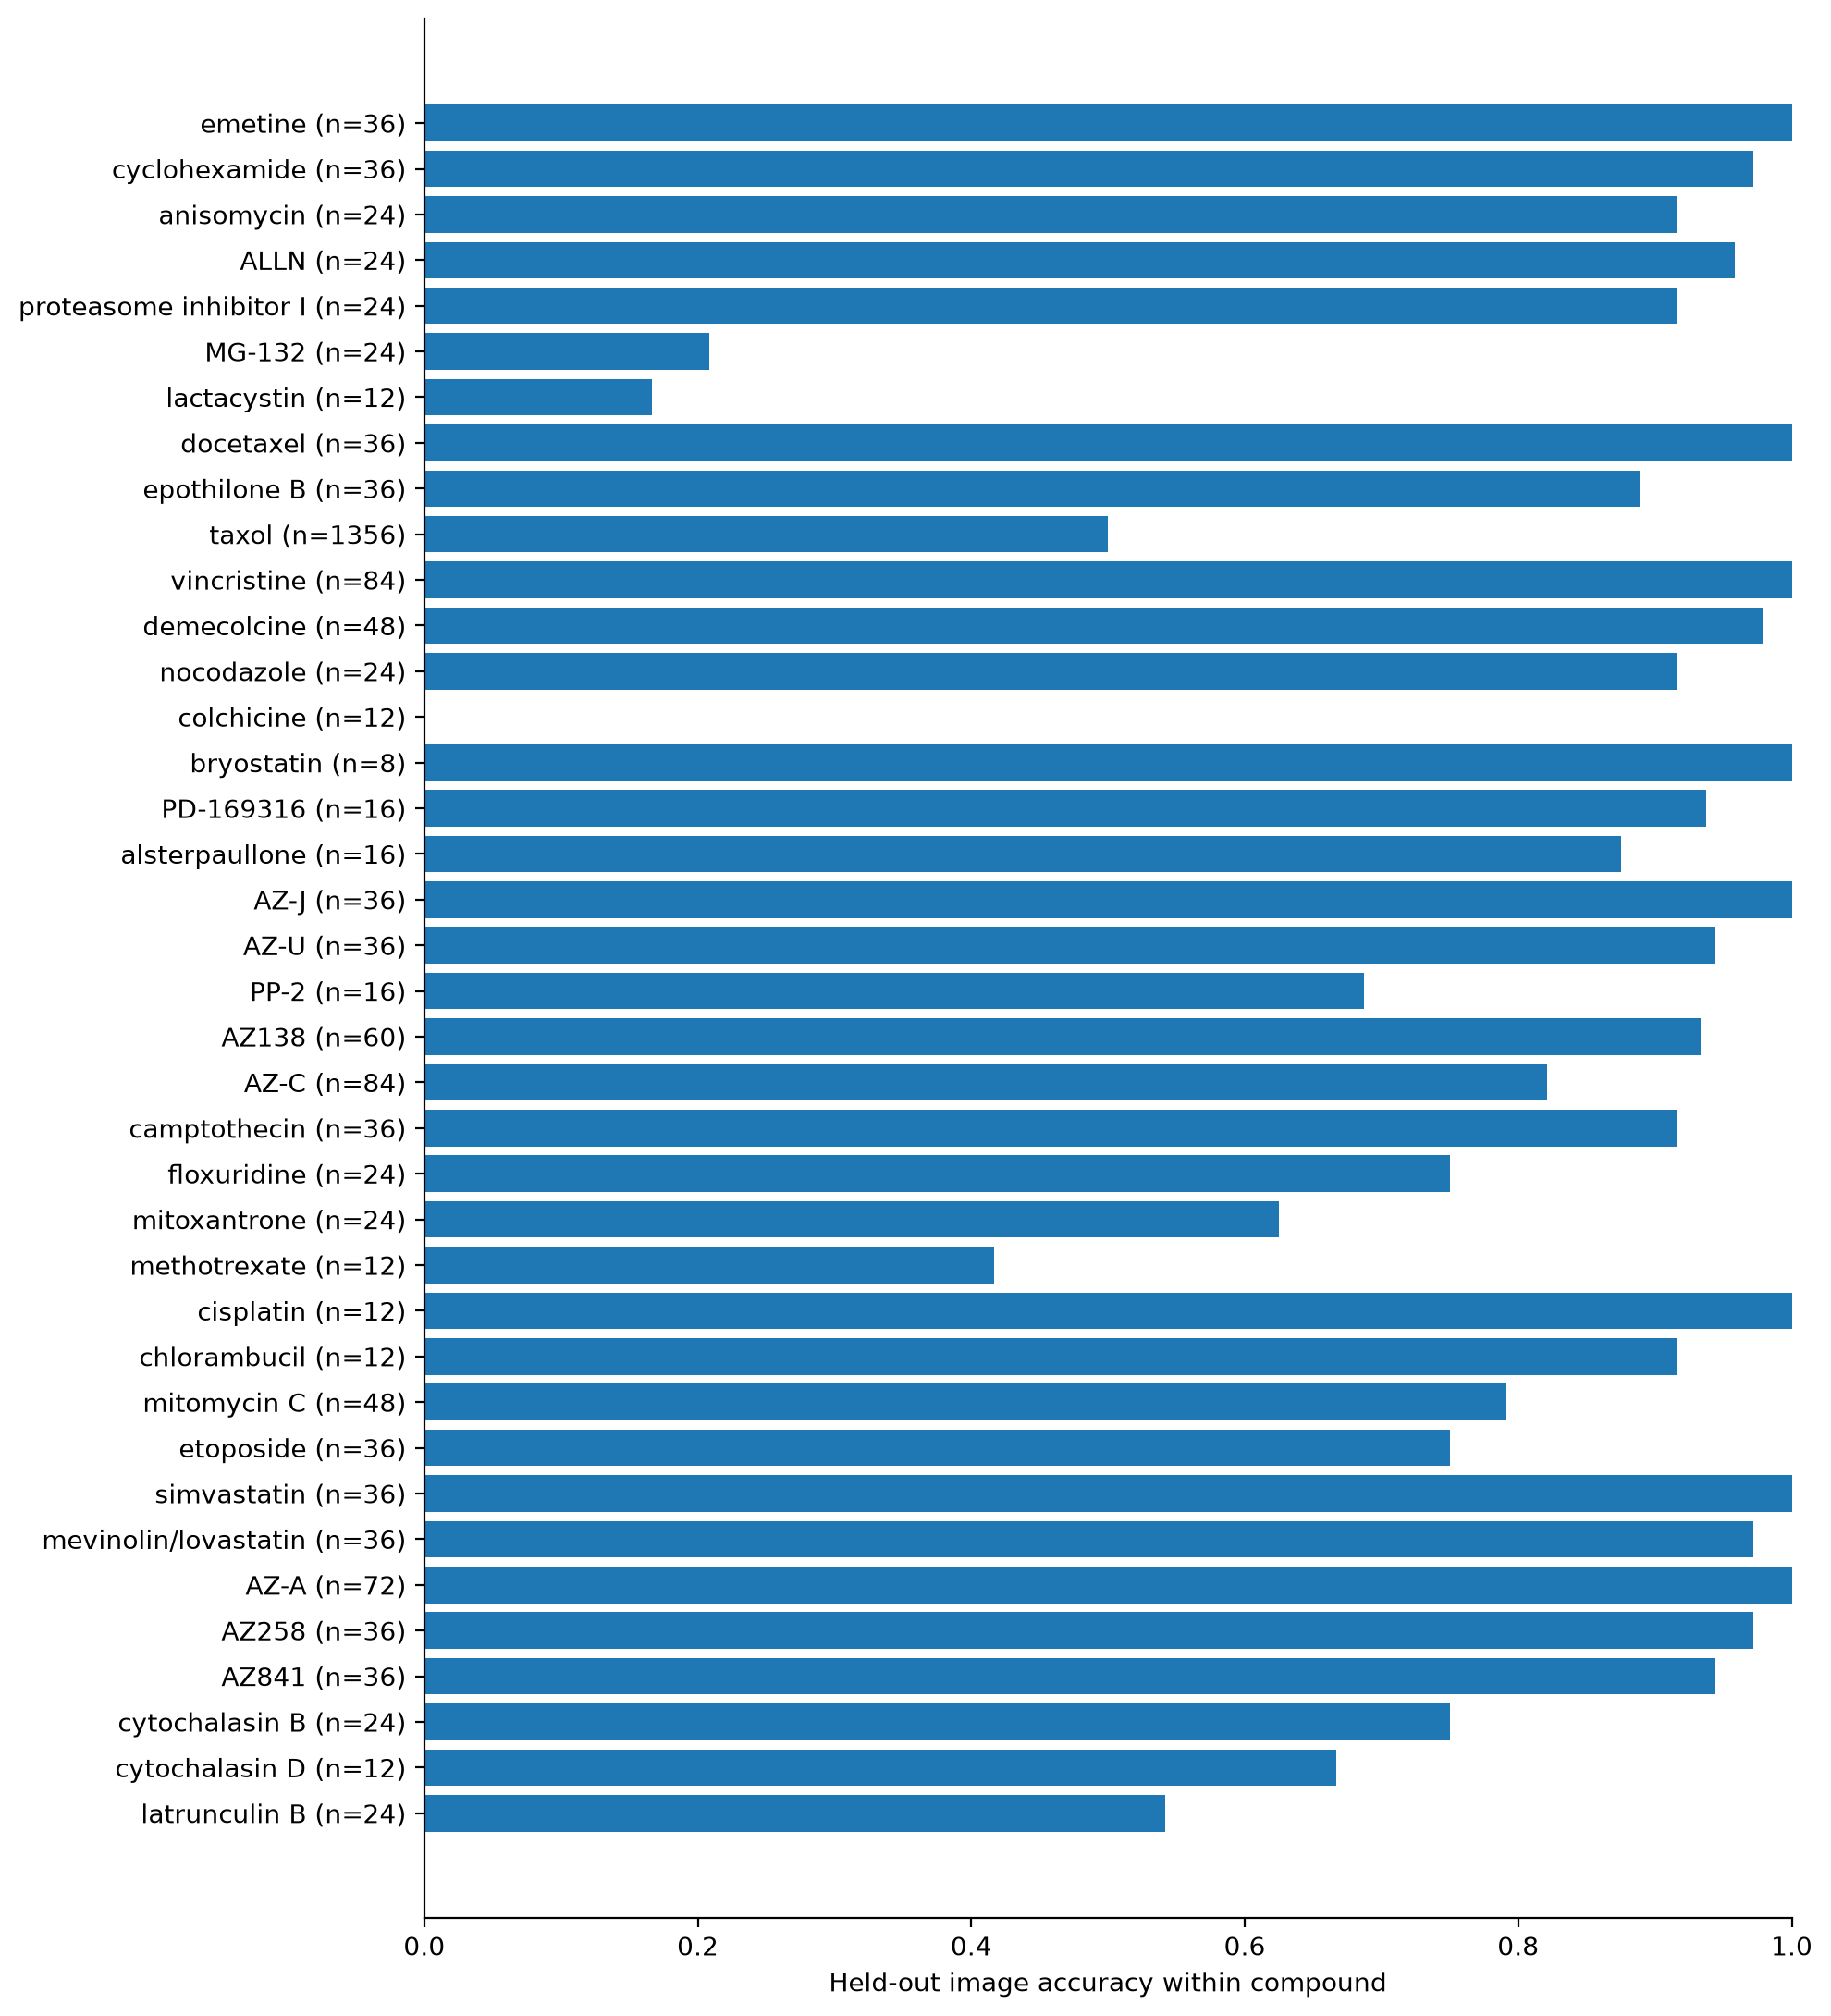

,moa,precision,recall,f1,support
0,Actin disruptors,0.722,0.650,0.684,60
1,Aurora kinase inhibitors,0.746,0.979,0.847,144
2,Cholesterol-lowering,0.423,0.986,0.592,72
3,DNA damage,0.800,0.815,0.807,108
4,DNA replication,0.657,0.740,0.696,96
5,Eg5 inhibitors,0.220,0.868,0.352,144
6,Epithelial,0.494,0.920,0.643,88
7,Kinase inhibitors,0.787,0.925,0.851,40
8,Microtubule destabilizers,0.841,0.911,0.874,168
9,Microtubule stabilizers,0.976,0.522,0.681,1428


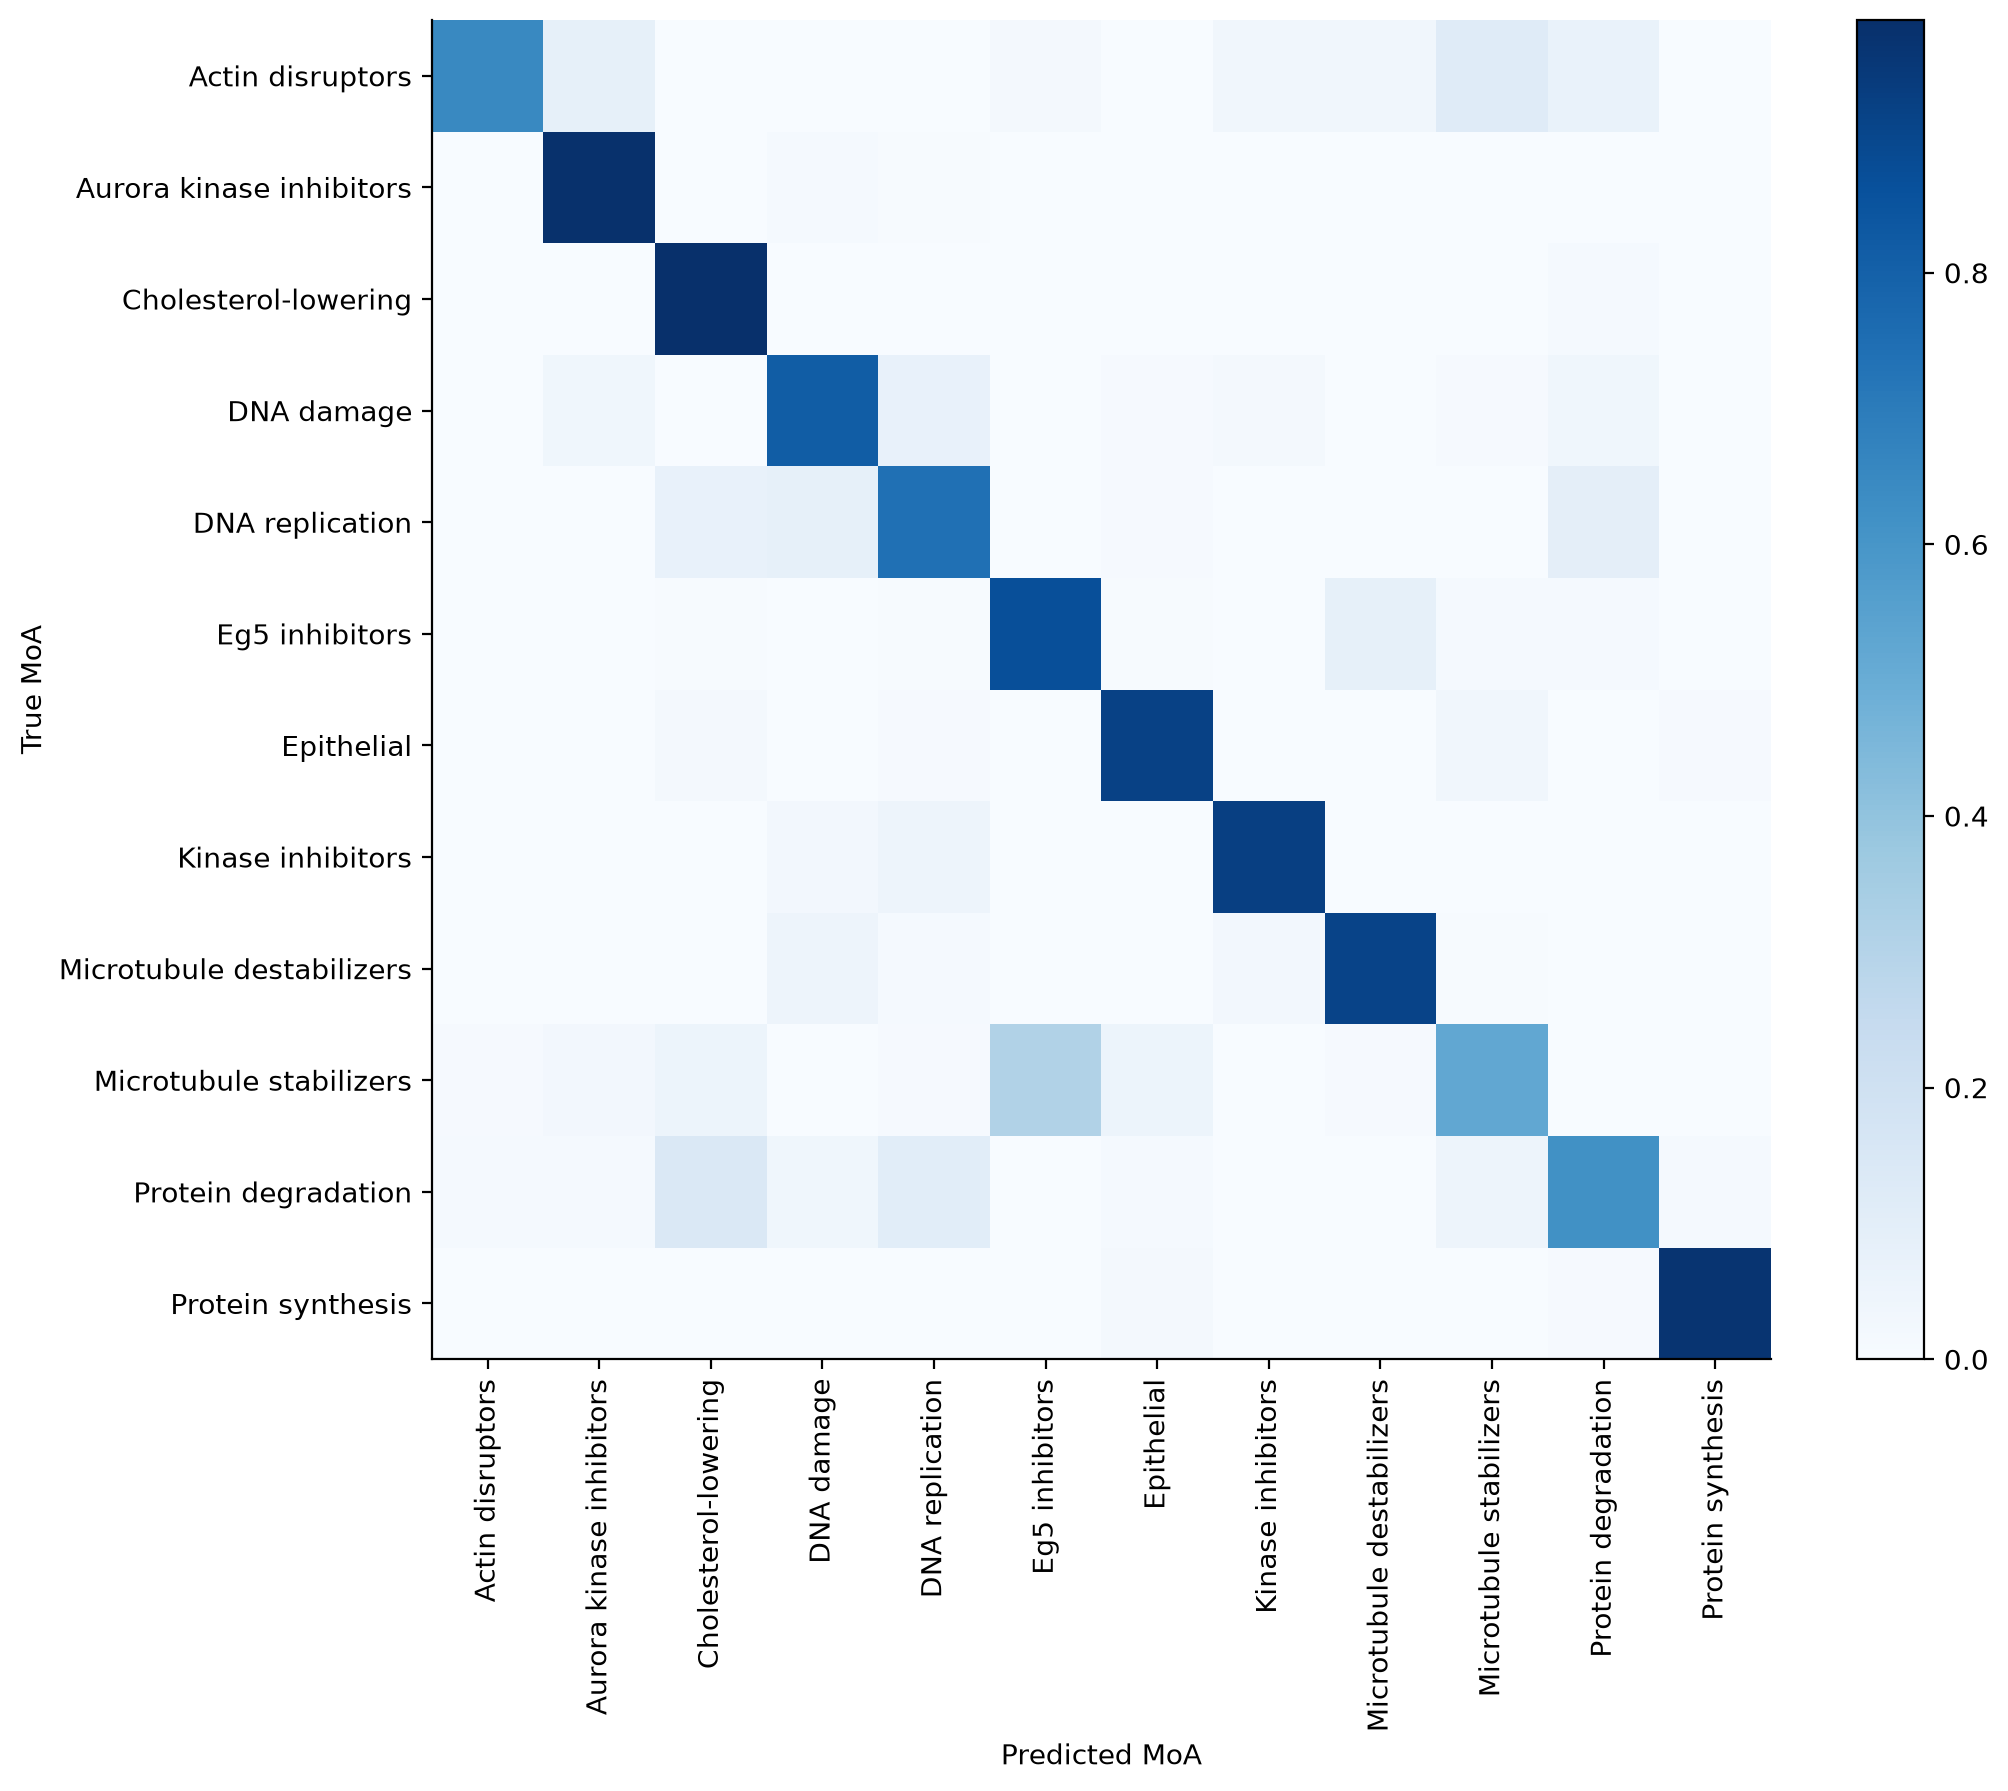

In [33]:
p = runs[PRIMARY_RUN]["predictions"]
per_compound = p.groupby(["true_moa", "test_compound"]).agg(
    images=("correct", "size"), accuracy=("correct", "mean"))
per_compound.to_csv(OUT / "primary_per_compound.csv")
display(per_compound.sort_values("accuracy"))

fig, ax = plt.subplots(figsize=(10, 11))
ordered = per_compound.reset_index().sort_values(["true_moa", "accuracy"])
labels = ordered.test_compound + " (n=" + ordered.images.astype(str) + ")"
ax.barh(labels, ordered.accuracy)
ax.set_xlim(0, 1)
ax.set_xlabel("Held-out image accuracy within compound")
savefig(fig, "compound_accuracy")

precision, recall, f1, support = precision_recall_fscore_support(
    p.true_label, p.predicted_label, labels=class_ids, zero_division=0)
per_class = pd.DataFrame({"moa": class_names, "precision": precision,
                          "recall": recall, "f1": f1, "support": support})
per_class.to_csv(OUT / "primary_per_class.csv", index=False)
display(per_class.round(3))

cm = confusion_matrix(p.true_label, p.predicted_label, labels=class_ids)
normalised = np.divide(cm, cm.sum(axis=1, keepdims=True),
                       out=np.zeros_like(cm, dtype=float), where=cm.sum(axis=1, keepdims=True) != 0)

matrix = normalised
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(matrix, cmap="Blues")
ax.set_xticks(class_ids); ax.set_yticks(class_ids)
ax.set_xticklabels(class_names, rotation=90); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted MoA"); ax.set_ylabel("True MoA")
fig.colorbar(im, ax=ax)
savefig(fig, "confusion_row_normalised")

The unequal compound size explains the difference between pooled image accuracy (67.1%) and mean accuracy across compounds (80.6%). Taxol accounts for 1,356 out of the 2,528 pooled test images and 678 of the 831 errors in the primary run. Its immage accuracy is 50.0% and therefore strongly influences the pooled image score.

Colchicine and lactacystin MoAs are misclassified at the compound level in all three runs. In the primary run, microtubule stabilizers have high precision (97.6%) but lower recall (52.2%), while Eg5 inhibitors show the reverse relationship with high recall (86.8%) but low precision (22.1%). Interestingly, many microtubule stabilizer images are predicted as Eg5 inhibitors.

## Approximate uncertainty for mean compound image accuracy

This stratified bootstrap samples compounds with replacement within each MoA,
retaining each class's number of compounds. Images are not treated as
independent biological replicates. The interval describes variability in the
evaluated compounds conditional on the fitted predictions; overlapping LOCO
training sets and training randomness are not fully represented.

In [34]:
rng = np.random.default_rng(BOOTSTRAP_SEED)
groups = [g.accuracy.to_numpy() for _, g in per_compound.reset_index().groupby("true_moa")]
boot = np.concatenate([rng.choice(g, size=(N_BOOTSTRAP, len(g)), replace=True)
                       for g in groups], axis=1).mean(axis=1)
ci = pd.Series({"estimate": per_compound.accuracy.mean(),
                "lower_95": np.quantile(boot, .025), "upper_95": np.quantile(boot, .975)})
display(ci.to_frame("mean_compound_image_accuracy"))
ci.to_csv(OUT / "compound_accuracy_bootstrap.csv")

,mean_compound_image_accuracy
estimate,0.806229
lower_95,0.737353
upper_95,0.868763


In the primary run, the mean of the 38 per-compound image accuracies is 80.6%. Averaged across compounds, it signifies that the model classifies about four in five images correctly when each compounds receive equal weight, regardless of how many images it contains. Thus, this average does not describe every compound and is dependent on which compounds is held-out.

To see how much the 80.6% average depends on which compounds are represented, the 38 observed compound were repeatedly resampled. The middle 95% of the resulting averages fell between 73.7% and 86.9%. This shows meaningful uncertainty.

## Summary

Across three complete leave-ont-compound-out runs, the model correctly identified 35/38, 35/38, and 36/38 compounds. For comparison, the training-fold majority baseline only identified 2/38 in each run. However, image accuracy was lower, ranging from 67.1% to 74.5%.

Performance varied between compounds. Taxol contributed most of the primary run's image errors due to it representing over half of all the test images. Colchicine and lactacystin were found to be misclassified at the compound level in all three runs. The primary run's mean per-compound image accuracy was 80.6% when every compound received equal weight, with a bootstrap interval of 73.7%-86.9%.

These results show that the model can identify the annotated MoA of many compounds unseen during training within the BBBC021 subset.